# Processing Status Dashboard

Shows which tiles have been processed by reading:
- `tile_list.geojson` — all tiles with a `land` boolean column (static, created by notebook 01)
- Icechunk commit history — the single source of truth for processed tiles

Use `config/config_v1.txt` (reads credentials from env vars) or
`config/config_with_secrets_v1.txt` (literal credentials, gitignored) in the first cell.

In [1]:
import sys
from pathlib import Path

import icechunk
import matplotlib.pyplot as plt
import geopandas as gpd

sys.path.insert(0, str(Path.cwd().parent))
from icechunk_github_actions_demo import Config, list_processed_tiles

# Use config_with_secrets_v1.txt for local runs; config_v1.txt reads credentials from env vars.
config = Config("config/config_with_secrets_v1.txt")

## Load tile list and check Icechunk history

In [2]:
tile_gdf = gpd.read_file(config.TILE_LIST_PATH)
land_set = {(int(r["row"]), int(r["col"])) for _, r in tile_gdf.iterrows() if r["land"]}
land_set

ERROR 1: PROJ: proj_create_from_database: Open of /home/eric/repos/icechunk_github_actions_zarr_synergy/icechunk_github_actions_demo/.pixi/envs/default/share/proj failed


{(0, 8),
 (0, 9),
 (0, 10),
 (0, 11),
 (0, 12),
 (0, 13),
 (0, 14),
 (0, 15),
 (0, 16),
 (0, 19),
 (0, 20),
 (0, 22),
 (0, 23),
 (0, 27),
 (1, 0),
 (1, 1),
 (1, 2),
 (1, 3),
 (1, 4),
 (1, 5),
 (1, 6),
 (1, 7),
 (1, 8),
 (1, 9),
 (1, 10),
 (1, 11),
 (1, 12),
 (1, 13),
 (1, 14),
 (1, 15),
 (1, 16),
 (1, 19),
 (1, 20),
 (1, 21),
 (1, 23),
 (1, 24),
 (1, 25),
 (1, 26),
 (1, 27),
 (1, 28),
 (1, 29),
 (1, 30),
 (1, 31),
 (1, 32),
 (1, 33),
 (1, 35),
 (2, 0),
 (2, 1),
 (2, 2),
 (2, 3),
 (2, 4),
 (2, 5),
 (2, 6),
 (2, 7),
 (2, 8),
 (2, 9),
 (2, 10),
 (2, 11),
 (2, 12),
 (2, 13),
 (2, 14),
 (2, 15),
 (2, 16),
 (2, 18),
 (2, 19),
 (2, 20),
 (2, 21),
 (2, 22),
 (2, 23),
 (2, 24),
 (2, 25),
 (2, 26),
 (2, 27),
 (2, 28),
 (2, 29),
 (2, 30),
 (2, 31),
 (2, 32),
 (2, 33),
 (2, 34),
 (2, 35),
 (3, 1),
 (3, 2),
 (3, 3),
 (3, 4),
 (3, 5),
 (3, 6),
 (3, 7),
 (3, 8),
 (3, 9),
 (3, 10),
 (3, 11),
 (3, 12),
 (3, 17),
 (3, 18),
 (3, 19),
 (3, 20),
 (3, 21),
 (3, 22),
 (3, 23),
 (3, 24),
 (3, 25),
 (3, 26),
 

In [3]:
storage = icechunk.azure_storage(
    account=config.AZURE_STORAGE_ACCOUNT,
    container=config.AZURE_CONTAINER,
    prefix=config.ICECHUNK_PREFIX,
    sas_token=config.AZURE_STORAGE_SAS_TOKEN,
)
repo = icechunk.Repository.open(storage)

In [4]:
processed_set = list_processed_tiles(repo)
processed_set

set()

In [5]:
remaining = land_set - processed_set

print(f"Land tiles:  {len(land_set)}")
print(f"Processed:   {len(processed_set)}")
print(f"Remaining:   {len(remaining)}")
print(f"Progress:    {100 * len(processed_set) / len(land_set):.1f}%")

Land tiles:  381
Processed:   0
Remaining:   381
Progress:    0.0%


## Visualize tile grid

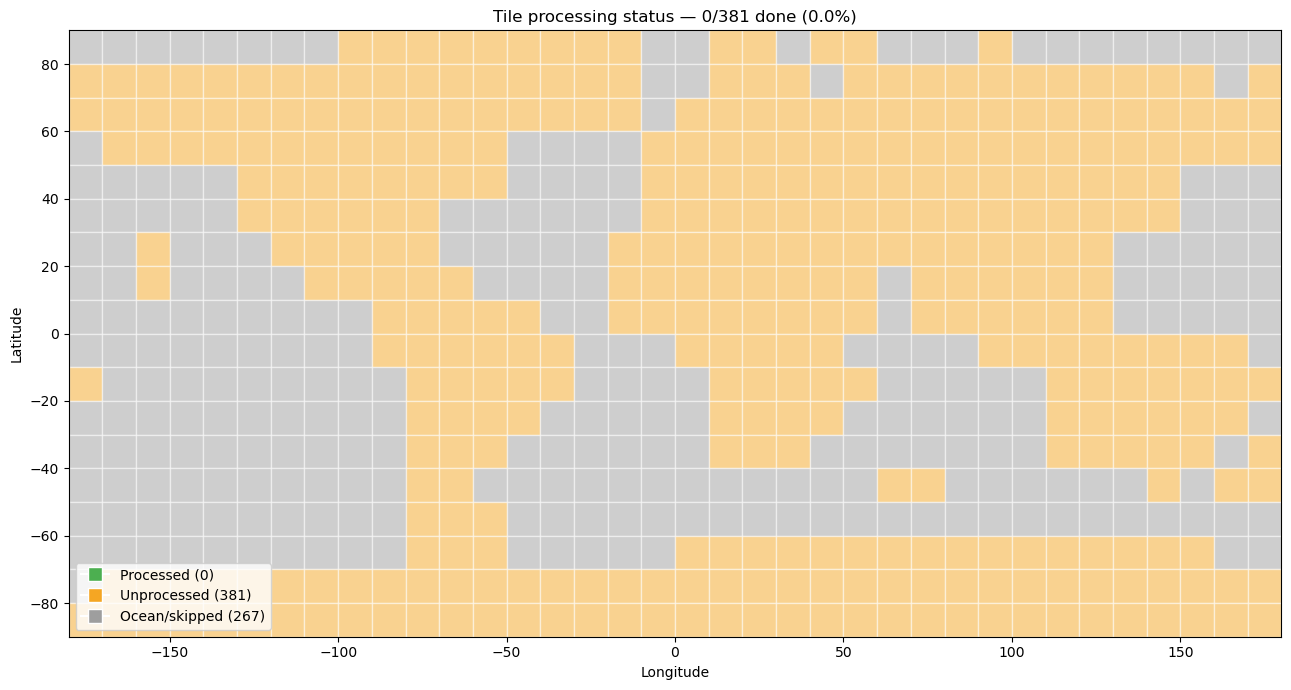

In [13]:
# assign status to each tile for plotting, either "processed", "unprocessed", or "skipped"
tile_gdf["status"] = tile_gdf.apply(
    lambda r: "processed" if (r["row"], r["col"]) in processed_set else "unprocessed"
    if (r["row"], r["col"]) in land_set
    else "skipped",
    axis=1,
)

color_map = {"processed": "#4caf50", "unprocessed": "#f5a623", "skipped": "#9e9e9e"}


f, ax = plt.subplots(figsize=(14, 7))
# plot the tiles colored by status, with white edges and alpha=0.5
tile_plot = tile_gdf.plot(
    ax=ax,
    #column="status",
    categorical=True,
    legend=True,
    color=tile_gdf["status"].map(color_map),
    edgecolor="white",
    alpha=0.5,
)

ax.set_xlim(-180, 180)
ax.set_ylim(-90, 90)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
ax.set_title(
    f"Tile processing status — {len(processed_set)}/{len(land_set)} done "
    f"({100*len(processed_set)/len(land_set):.1f}%)"
)
# add legend with custom labels and colors
handles = [
    plt.Line2D([0], [0], marker="s", color="w", label=f"Processed ({len(processed_set)})", markerfacecolor=color_map["processed"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Unprocessed ({len(land_set) - len(processed_set)})", markerfacecolor=color_map["unprocessed"], markersize=10),
    plt.Line2D([0], [0], marker="s", color="w", label=f"Ocean/skipped ({len(tile_gdf) - len(land_set)})", markerfacecolor=color_map["skipped"], markersize=10),
]
ax.legend(handles=handles, loc="lower left")
f.tight_layout()


## List unprocessed tiles

In [14]:
if remaining:
    print("Unprocessed tiles (row, col):")
    for r, c in sorted(remaining):
        lat_min = -90 + r * config.TILE_SIZE_DEG
        lon_min = -180 + c * config.TILE_SIZE_DEG
        print(f"  row={r}, col={c}  lat=[{lat_min:.0f}, {lat_min+10:.0f}]  lon=[{lon_min:.0f}, {lon_min+10:.0f}]")
else:
    print("All land tiles processed.")

Unprocessed tiles (row, col):
  row=0, col=8  lat=[-90, -80]  lon=[-100, -90]
  row=0, col=9  lat=[-90, -80]  lon=[-90, -80]
  row=0, col=10  lat=[-90, -80]  lon=[-80, -70]
  row=0, col=11  lat=[-90, -80]  lon=[-70, -60]
  row=0, col=12  lat=[-90, -80]  lon=[-60, -50]
  row=0, col=13  lat=[-90, -80]  lon=[-50, -40]
  row=0, col=14  lat=[-90, -80]  lon=[-40, -30]
  row=0, col=15  lat=[-90, -80]  lon=[-30, -20]
  row=0, col=16  lat=[-90, -80]  lon=[-20, -10]
  row=0, col=19  lat=[-90, -80]  lon=[10, 20]
  row=0, col=20  lat=[-90, -80]  lon=[20, 30]
  row=0, col=22  lat=[-90, -80]  lon=[40, 50]
  row=0, col=23  lat=[-90, -80]  lon=[50, 60]
  row=0, col=27  lat=[-90, -80]  lon=[90, 100]
  row=1, col=0  lat=[-80, -70]  lon=[-180, -170]
  row=1, col=1  lat=[-80, -70]  lon=[-170, -160]
  row=1, col=2  lat=[-80, -70]  lon=[-160, -150]
  row=1, col=3  lat=[-80, -70]  lon=[-150, -140]
  row=1, col=4  lat=[-80, -70]  lon=[-140, -130]
  row=1, col=5  lat=[-80, -70]  lon=[-130, -120]
  row=1, col=6